<a href="https://colab.research.google.com/github/shubham300701/AI-Meter-Remark-Classification/blob/main/LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic Regression (LR)**

Before Running of the Code, Please Upload Two Files in Google Colab Directory
- dataset.csv ( Columns Names "TEXT_REMARKS" and "ACTION_CATEGORY")


**Structure of 'dataset.csv':**
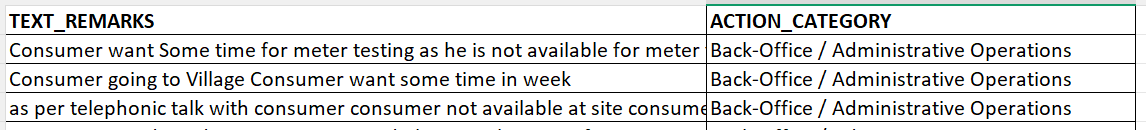


In [2]:
# ===============================
# Meter Remark Classification AI
# Logistic Regression + TF-IDF
# ===============================

# 1 Import Libraries
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# 2 Load Dataset
data = pd.read_csv("dataset.csv")

print("Dataset Loaded Successfully")
print(data.head())


# 3 Define Input and Output
X = data['TEXT_REMARKS']
y = data['ACTION_CATEGORY']


# 4 TF-IDF Feature Extraction
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF Vectorization Completed")


# 5 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

print("Dataset Split Completed")


# 6 Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Training Completed")


# 7 Model Evaluation
y_pred = model.predict(X_test)

print("\nModel Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# 8 Save Model and TF-IDF
pickle.dump(model, open("meter_remark_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

print("\nModel Saved Successfully")


# 9 Prediction Function
def predict_department(text):

    text_vec = tfidf.transform([text])

    prediction = model.predict(text_vec)

    return prediction[0]


# 10 User Input System
print("\n===== Meter Remark Classification System =====")

while True:

    remark = input("\nEnter Meter Testing Remark (or type exit): ")

    if remark.lower() == "exit":
        break

    result = predict_department(remark)

    print("Concerned Department:", result)

Dataset Loaded Successfully
                                        TEXT_REMARKS  \
0  Consumer want Some time for meter testing as h...   
1  Consumer going to Village Consumer want some t...   
2  as per telephonic talk with consumer consumer ...   
3  No person at side and no response on said phon...   
4  No person at side and no response on said phon...   

                           ACTION_CATEGORY  Unnamed: 2  Unnamed: 3  \
0  Back-Office / Administrative Operations         NaN         NaN   
1  Back-Office / Administrative Operations         NaN         NaN   
2  Back-Office / Administrative Operations         NaN         NaN   
3  Back-Office / Administrative Operations         NaN         NaN   
4  Back-Office / Administrative Operations         NaN         NaN   

   Unnamed: 4  Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  \
0         NaN         NaN         NaN         NaN         NaN         NaN   
1         NaN         NaN         NaN         NaN         Na

Link: https://colab.research.google.com/drive/1lYjQ5igsLIVzLZ-TuBgkgLAvvB9E7FZa?usp=sharing